<a href="https://colab.research.google.com/github/sanjanareddy1443/Air-quality-prediction/blob/main/Untitled31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Dataset
df = pd.read_csv(
    r"/content/drive/MyDrive/Air_quality.csv",
    sep=None,
    engine="python"
)

#  Data Preprocessing
# Remove fully empty rows
df = df.dropna(how='all')

# Drop unwanted unnamed columns
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore')

# Replace missing value marker
df.replace(-200, np.nan, inplace=True)

# Drop rows with missing target
df = df.dropna(subset=['CO(GT)'])

# Fill remaining missing values with median
df = df.fillna(df.median(numeric_only=True))
print(df)


            Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0     10/03/2004  18:00:00     2.6       1360.0     150.0      11.9   
1     10/03/2004  19:00:00     2.0       1292.0     112.0       9.4   
2     10/03/2004  20:00:00     2.2       1402.0      88.0       9.0   
3     10/03/2004  21:00:00     2.2       1376.0      80.0       9.2   
4     10/03/2004  22:00:00     1.6       1272.0      51.0       6.5   
...          ...       ...     ...          ...       ...       ...   
9352  04/04/2005  10:00:00     3.1       1314.0     154.0      13.5   
9353  04/04/2005  11:00:00     2.4       1163.0     154.0      11.4   
9354  04/04/2005  12:00:00     2.4       1142.0     154.0      12.4   
9355  04/04/2005  13:00:00     2.1       1003.0     154.0       9.5   
9356  04/04/2005  14:00:00     2.2       1071.0     154.0      11.9   

      PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
0            1046.0    166.0        1056.0    113.0        1692.0   
1        

In [ ]:

#  Feature Selection
features = [
    'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
    'PT08.S5(O3)', 'T', 'RH', 'AH'
]

X = df[features]
y = df['CO(GT)']

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train Decision Tree Regressor
model = DecisionTreeRegressor(max_depth=8,random_state=42)

model.fit(X_train, y_train)



DecisionTreeRegressor(max_depth=8, random_state=42)

In [ ]:
# Make Predictions
y_pred = model.predict(X_test)
# 8. Convert CO → Air Quality Category
def air_quality_label(co):
    if co <= 4.4:
        return "Good"
    elif co <= 9.4:
        return "Moderate"
    elif co <= 12.4:
        return "Unhealthy for Sensitive Groups"
    elif co <= 15.4:
        return "poor"
    else:
        return "hazardous"
air_quality = [air_quality_label(co) for co in y_pred]
# 9. Final Results Table
results = pd.DataFrame({
    "Actual CO(GT)": y_test.values,
    "Predicted CO(GT)": y_pred,
    "Air Quality Warnings": air_quality
})
print("\nSample Predictions:")
print(results.head())



Sample Predictions:
   Actual CO(GT)  Predicted CO(GT) Air Quality Warnings
0            7.1          5.475000             Moderate
1            0.9          0.787912                 Good
2            3.8          3.582609                 Good
3            2.3          1.804902                 Good
4            0.9          0.947727                 Good


In [ ]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score  : {r2:.4f}")

Mean Squared Error: 0.2149
R-squared Score  : 0.8968


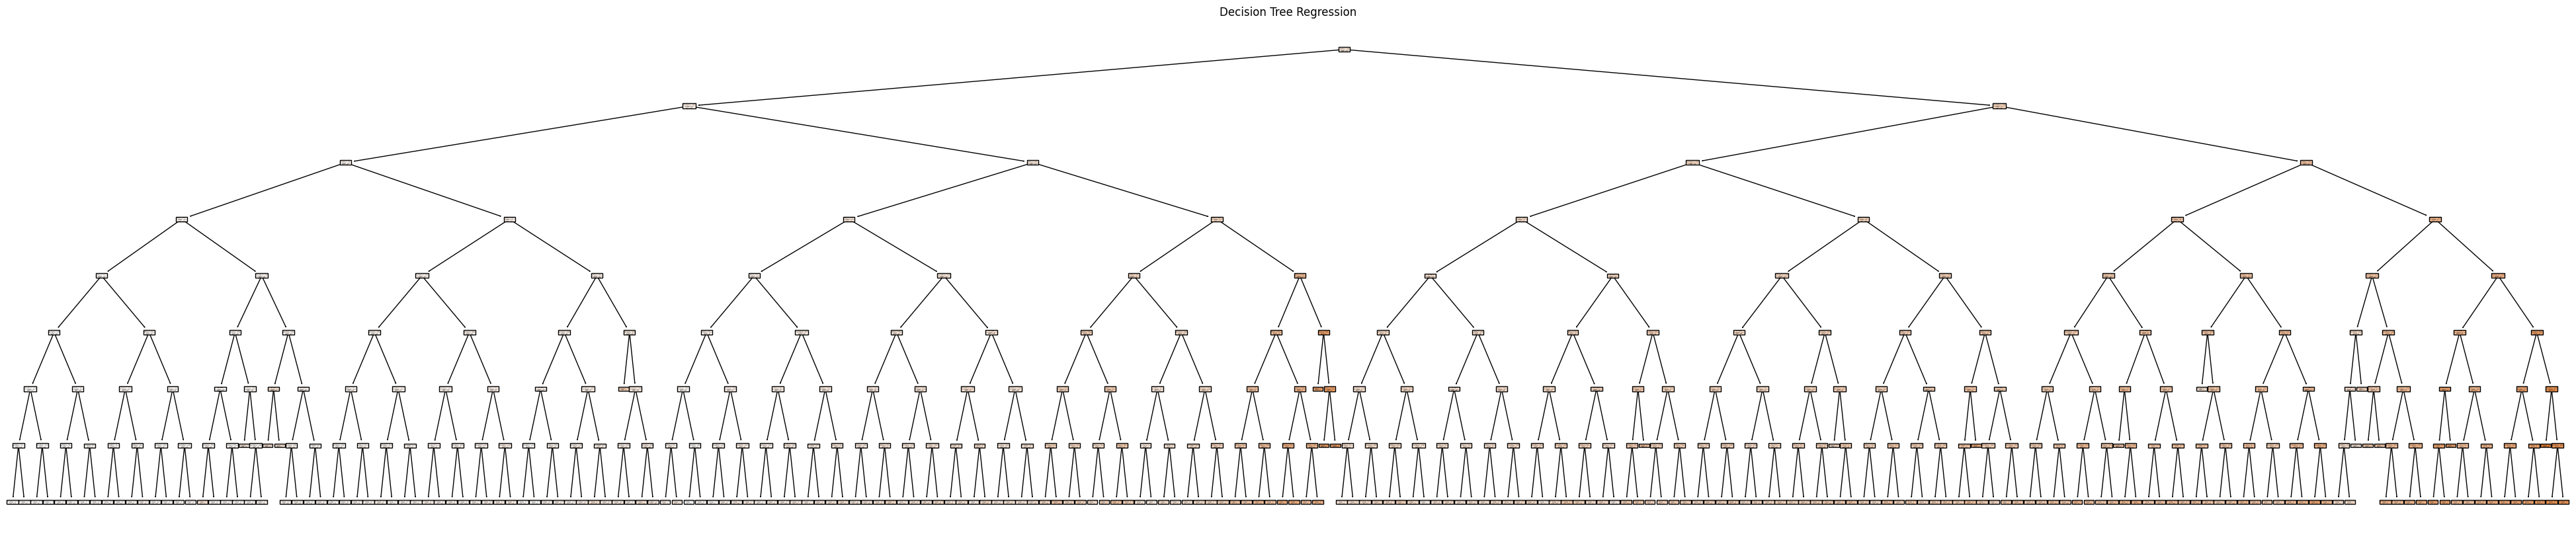

In [ ]:
plt.figure(figsize=(50,10))
plot_tree(model, filled=True, feature_names=features)
plt.title("Decision Tree Regression")
plt.show()

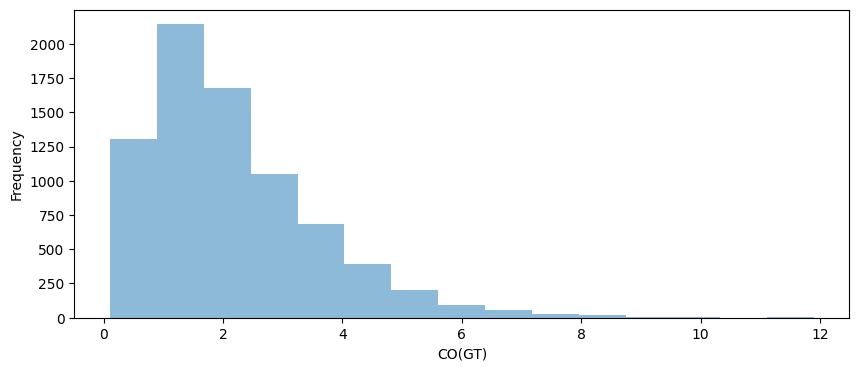

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(df['CO(GT)'],bins=15,alpha=0.5)
plt.xlabel("CO(GT)")
plt.ylabel("Frequency")
plt.show()

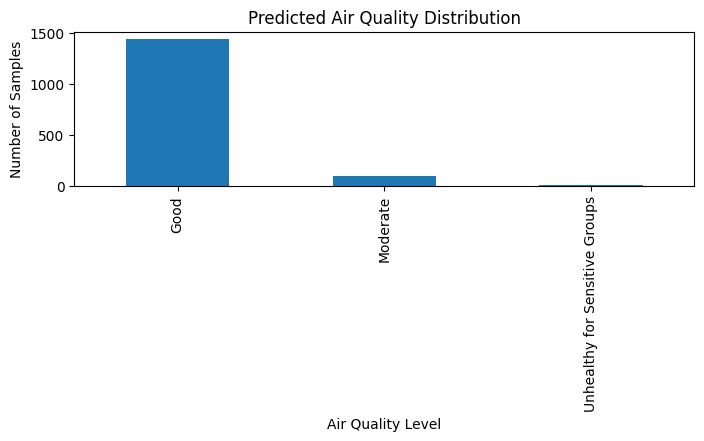

In [ ]:
# Visualization: Air Quality Distribution
plt.figure(figsize=(8, 2))
results['Air Quality Warnings'].value_counts().plot(kind='bar')
plt.title("Predicted Air Quality Distribution")
plt.ylabel("Number of Samples")
plt.xlabel("Air Quality Level")
plt.show()

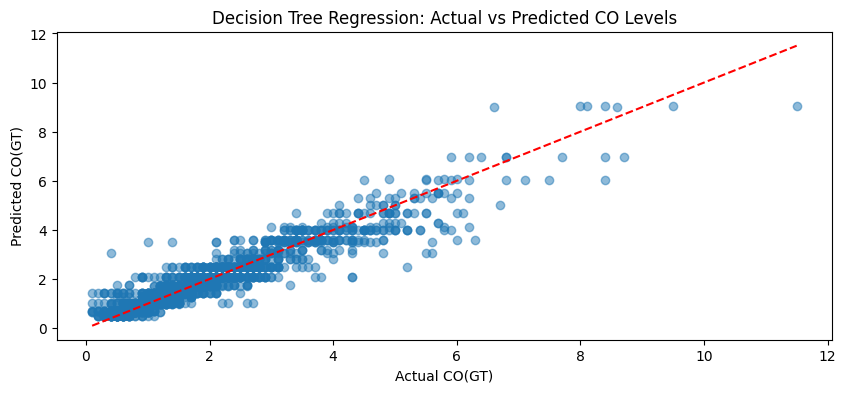

In [ ]:
 # Visualization: Actual vs Predicted
plt.figure(figsize=(10, 4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")
plt.title("Decision Tree Regression: Actual vs Predicted CO Levels")
plt.show()
